In [1]:
#Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Carregando o dataset
df = pd.read_csv("C:/Users/Usuario/Documents/Estudos CD/ecommerce-customer-churn-analysis/data/raw/Customer_Churn_Dataset.csv")

In [35]:
#primeiro EDA para entender o dataset
df.shape
df.head()
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


np.int64(0)

In [ ]:
#analise da coluna de churn
df['Churn'].value_counts()
df['Churn'].value_counts(normalize = True) * 100 #Percentual
sns.countplot(x = 'Churn', data = df)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64
Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64


<Axes: xlabel='Churn', ylabel='tenure'>

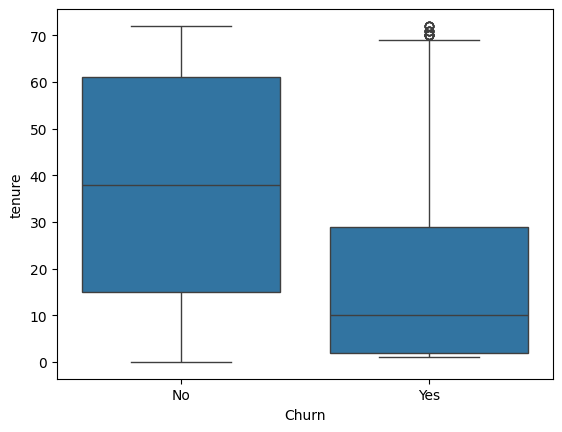

In [46]:
#entender a relação do tenure com o churn
media = df.groupby('Churn')['tenure'].mean()
print(media)
median = df.groupby('Churn')['tenure'].median()
print(median)
sns.boxplot(x = 'Churn', y = 'tenure', data = df)


<Axes: xlabel='tenure_group', ylabel='count'>

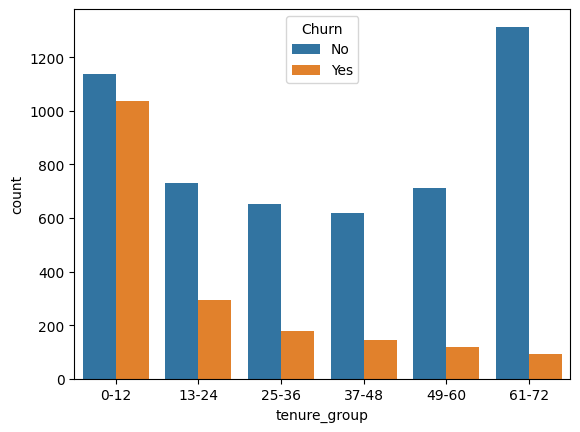

In [58]:
#criando as bins para o tenure
df['tenure_group'] = pd.cut(df['tenure'], bins = [0, 12, 24, 36, 48, 60, 72], labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72'])
sns.countplot(x = 'tenure_group', hue = 'Churn', data = df)

Churn                No        Yes
tenure_group                      
0-12          52.321839  47.678161
13-24         71.289062  28.710938
25-36         78.365385  21.634615
37-48         80.971129  19.028871
49-60         85.576923  14.423077


<Axes: xlabel='tenure_group', ylabel='count'>

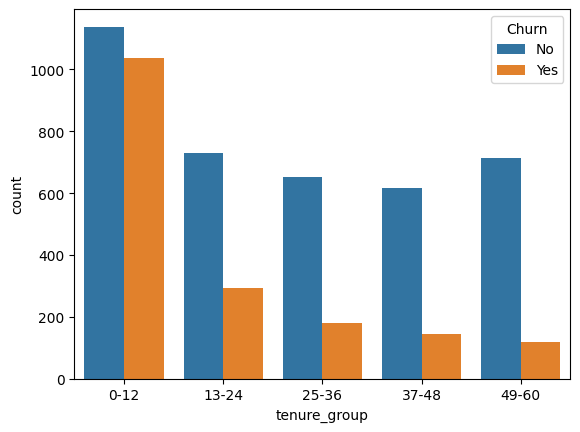

In [ ]:
#avaliando a relação do tenure com o churn
crosstab = pd.crosstab(df['tenure_group'], df['Churn'], normalize = 'index') * 100 #verificando o percentual de churn por grupo de tenure
print (crosstab)
sns.countplot(x = 'tenure_group', hue = 'Churn', data = df) #visualizando a relação do tenure com o churn